In [1]:
%run stochastic_lite.ipynb

In [2]:
####################
# Inputs
####################

# PSD ~ 1e-42 strain^2 / Hz
# PSD = 2 sigma**2 * deltaT = 2 * sigma**2 / Fs
# = sigma**2 / 512
# sigma = sqrt(1e-42 * 512)

sigma             = np.sqrt(512 * 1e-42) # strain
sigma_inj         = sigma/10.
NSegments         = 50
Fs                = 1024. # Hz
segmentDuration   = 64.0 # s
t0                = 0 # s
TAvg              = 4.0 # s

####################
# Computed quantities
####################

NSamplesPerSegment=int(segmentDuration*Fs) 
deltaT=1/Fs
fNyquist=1/(2*deltaT)
deltaF=1/segmentDuration
deltaFStoch=1/TAvg
NAvgs = 2 * int(segmentDuration / TAvg) - 1
jobDuration = NSegments * segmentDuration

In [3]:
# Theoretical PSD and sigma for white GWB and white noise

Nfreqs = int((Fs/2) / deltaFStoch)
alpha=3 # white signal
fref=25

w1w2bar, w1w2squaredbar,_,_ = window_factors(NSamplesPerSegment)
PSD_theor = 2*(sigma**2)*deltaT
Pgw_theor = 2*(sigma_inj**2)*deltaT

H_theor = (3*H0**2)/(10*np.pi**2*fref**3) # don't need *(P1.freqs/fref)**(alpha-3) for alpha=3
Y_theor = Pgw_theor/H_theor

var_theor = 1./((segmentDuration)*2*Nfreqs*deltaFStoch * H_theor**2/(PSD_theor**2))
var_theor = w1w2squaredbar / w1w2bar**2 * var_theor
sigma_theor = np.sqrt(var_theor)

print('sigma_theor =', sigma_theor)
print('Y_theor =', Y_theor)

sigma_theor = 0.0002666003559166893
Y_theor = 0.0004894401662160896


In [4]:
# simulate the time series data
noise1=sigma*np.random.randn(int(NSamplesPerSegment*NSegments))
noise2=sigma*np.random.randn(int(NSamplesPerSegment*NSegments))
inj=sigma_inj*np.random.randn(int(NSamplesPerSegment*NSegments))

times=np.arange(t0,t0+NSegments*segmentDuration,1/Fs)

d1=TimeSeries(times,noise1 + inj)
d2=TimeSeries(times,noise2 + inj)

In [5]:
# run stochastic pipeline
alpha=3
fref=25
Ys, sigs, Y_fs, var_fs, Y0_fs, var0_fs, segmentStartTimes, freqs=stochastic(d1,d2,segmentDuration,deltaFStoch,
                                                                            fref=fref,alpha=alpha)

/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_64979/2601316946.py:109: RuntimeWarning: divide by zero encountered in divide
  S0 = FrequencySeries(freqs, (3*H0**2)/(10*np.pi**2*freqs**3))
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_64979/2601316946.py:110: RuntimeWarning: invalid value encountered in multiply
  S_alpha = FrequencySeries(freqs, S0.data * (freqs/fref)**alpha )
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_64979/2601316946.py:119: ComplexWarning: Casting complex values to real discards the imaginary part
  Y0_fs[:,II],var0_fs[:,II] = Y0_f.data, var0_f.data
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_64979/2601316946.py:131: ComplexWarning: Casting complex values to real discards the imaginary part
  Y_fs[:,II],var_fs[:,II] = Y_f.data, var_f.data
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_64979/2601316946.py:137: ComplexWarning: Casting complex values to real discards the imaginary part
  Ys[II], sigs[

stochastic: Done with Interval 1 / 95
	Y       = 4.923435e-04
	sigma   = 2.637508e-04
	SNR     = 1.866699
stochastic: Done with Interval 2 / 95
	Y       = 2.555071e-04
	sigma   = 2.642347e-04
	SNR     = 0.966970
stochastic: Done with Interval 3 / 95
	Y       = 4.639903e-04
	sigma   = 2.655007e-04
	SNR     = 1.747605
stochastic: Done with Interval 4 / 95
	Y       = 3.611205e-04
	sigma   = 2.651964e-04
	SNR     = 1.361709
stochastic: Done with Interval 5 / 95
	Y       = 4.771462e-04
	sigma   = 2.638146e-04
	SNR     = 1.808642
stochastic: Done with Interval 6 / 95
	Y       = 3.116088e-04
	sigma   = 2.642140e-04
	SNR     = 1.179380
stochastic: Done with Interval 7 / 95
	Y       = 5.936889e-04
	sigma   = 2.650962e-04
	SNR     = 2.239523
stochastic: Done with Interval 8 / 95
	Y       = 2.708825e-04
	sigma   = 2.638872e-04
	SNR     = 1.026509
stochastic: Done with Interval 9 / 95
	Y       = 6.795602e-04
	sigma   = 2.621430e-04
	SNR     = 2.592327
stochastic: Done with Interval 10 / 95
	Y     

In [6]:
# combine point estimates and error bars assuming that stochastic was run with fixed alpha
Y_opt, sig_opt = postprocessing(Ys,sigs,jobDuration,segmentDuration,deltaFStoch,deltaT,bufferSecs=0)

print('Y_opt =', Y_opt)
print('sig_opt =', sig_opt)

Y_opt_alt= 0.000534040143792602
s_opt_alt= 2.8784933271000507e-05
Y_opt= 0.0005340401437926022
s_opt= 2.8784933271000514e-05
bias= 1.0173198893493407
Y_opt = 0.0005340401437926022
sig_opt = 2.8784933271000514e-05


In [7]:
# ALTERNATIVE CALCULATION!!!
# first combine spectra over segments

Y_f,var_f=postprocessing_spectra(Y_fs,var_fs,Ys, sigs,jobDuration,segmentDuration,
                                 deltaFStoch,deltaT)

# then combine over freqs, weighting as appropriate
f_filter=freqs>0.
Y_opt_alt,sig_opt_alt=calc_Y_sigma_from_Yf_varf(Y_f[f_filter],
                          var_f[f_filter],
                          freqs=freqs[f_filter],
                          alpha=3,
                          fref=25)

print('Y_opt_alt =', Y_opt_alt)
print('sig_opt_alt =', sig_opt_alt)
#print('Optimal SNR [alpha=3]: %f'%(y_opt/s_opt))

Y_opt_bb= 0.00046483901143550975
s_opt_bb= 2.875570854983365e-05
bias = 1.0173198893493407
Y_opt_nb= -4.726795576898095e-10
s_opt_nb= 1.323409290414865e-09
broadband v_o= 1.4576467176624776e-09
narowband v_o= 2.9864483762076296e-18
broadband v_e= 1.4887468283588964e-09
narowband v_e= 3.0436400894878263e-18
broadband Y_o= 0.00044827694719132304
narowband Y_o= 2276.768893886192
broadband Y_e= 0.0004817875665636221
narowband Y_e= 2125.344386904759
broadband Y/sig^2_o= 307534.70080198324
narowband Y/sig^2_o= -397498612.8170328
broadband Y/sig^2_e= 323619.5418765159
narowband Y/sig^2_e= 84343716.18239665
Y_opt_alt = 0.00046486291203017124
sig_opt_alt = 2.875581615390467e-05


/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_64395/3524007381.py:51: RuntimeWarning: divide by zero encountered in divide
  v_f_o = 1./np.sum(1./var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_64395/3524007381.py:52: RuntimeWarning: divide by zero encountered in divide
  v_f_e = 1./np.sum(1./var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_64395/3524007381.py:56: RuntimeWarning: invalid value encountered in multiply
  Y_f_o = X_f_o * v_f_o
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_64395/3524007381.py:57: RuntimeWarning: invalid value encountered in multiply
  Y_f_e = X_f_e * v_f_e
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_64395/3524007381.py:66: RuntimeWarning: invalid value encountered in divide
  Y_f = ( X_f_o*(1- 0.5*k*v_o * sig_m2) + X_f_e*(1. - 0.5*k*v_e * sig_m2)) / (1./v_f_o + 1./v_f_e - k*sig_m2_f)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_64395/3524007

In [8]:
# ALTERNATIVE CALCULATION!!!
# first combine spectra over segments

Y_f_a,var_f_a=postprocessing_spectra(Y_fs_a,var_fs_a,Ys, sigs,jobDuration,segmentDuration,
                                 deltaFStoch,deltaT)

# then combine over freqs, weighting as appropriate
f_filter=freqs>0.
Y_opt_alt,sig_opt_alt=calc_Y_sigma_from_Yf_varf(Y_f_a[f_filter],var_f_a[f_filter],freqs=None)

print('Y_opt_alt =', Y_opt_alt)
print('sig_opt_alt =', sig_opt_alt)
#print('Optimal SNR [alpha=3]: %f'%(y_opt/s_opt))

Y_opt_bb= 0.00046483901143550975
s_opt_bb= 2.875570854983365e-05
bias = 1.0173198893493407
Y_opt_nb= 0.0004648390114355098
s_opt_nb= 2.9253754240078657e-05
broadband v_o= 1.4576467176624776e-09
narowband v_o= 1.4576467176624776e-09
broadband v_e= 1.4887468283588964e-09
narowband v_e= 1.4887468283588966e-09
broadband Y_o= 0.00044827694719132304
narowband Y_o= 0.9232085432073989
broadband Y_e= 0.0004817875665636221
narowband Y_e= 0.995473811048476
broadband Y/sig^2_o= 307534.70080198324
narowband Y/sig^2_o= 307534.70080198324
broadband Y/sig^2_e= 323619.5418765159
narowband Y/sig^2_e= 323619.5418765159
Y_opt_alt = 0.00046483901143550975
sig_opt_alt = 2.875570854983365e-05


/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_64395/3524007381.py:51: RuntimeWarning: divide by zero encountered in divide
  v_f_o = 1./np.sum(1./var_fs_odds,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_64395/3524007381.py:52: RuntimeWarning: divide by zero encountered in divide
  v_f_e = 1./np.sum(1./var_fs_evens,axis=1)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_64395/3524007381.py:56: RuntimeWarning: invalid value encountered in multiply
  Y_f_o = X_f_o * v_f_o
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_64395/3524007381.py:57: RuntimeWarning: invalid value encountered in multiply
  Y_f_e = X_f_e * v_f_e
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_64395/3524007381.py:66: RuntimeWarning: invalid value encountered in divide
  Y_f = ( X_f_o*(1- 0.5*k*v_o * sig_m2) + X_f_e*(1. - 0.5*k*v_e * sig_m2)) / (1./v_f_o + 1./v_f_e - k*sig_m2_f)
/var/folders/h9/8jj76gb51nq2gjkzk76xh3l415264w/T/ipykernel_64395/3524007

In [9]:
var = 1/np.sum(1/var_f[f_filter])
Y = np.sum(Y_f[f_filter]/var_f[f_filter])/np.sum(var_f[f_filter])
s = np.sqrt(var)
print(Y,s)

fref=25
alpha=3
ws = (freqs/fref)**alpha

var_w = 1/np.sum(ws[f_filter]**2/var_f[f_filter])
Y_w = np.sum(ws[f_filter]*Y_f[f_filter]/var_f[f_filter])/np.sum(ws[f_filter]**2/var_f[f_filter])

s_w = np.sqrt(var_w)
print(Y_w, s_w)

-7634.951752458648 1.3008782235264206e-09
0.0004648629120301711 2.875581615390467e-05


In [10]:
print(freqs[1]-freqs[0])

0.25


15:08 bilby INFO    : Running for label 'GWB_powerlaw', output will be saved to 'outdir'
15:09 bilby INFO    : Analysis priors:
15:09 bilby INFO    : A=Uniform(minimum=1e-10, maximum=0.001, name='A', latex_label='A', unit=None, boundary=None)
15:09 bilby INFO    : alpha=Uniform(minimum=-5, maximum=5, name='alpha', latex_label='alpha', unit=None, boundary=None)
15:09 bilby INFO    : Analysis likelihood class: <class '__main__.BasicPowerLawGWBLikelihood'>
15:09 bilby INFO    : Analysis likelihood noise evidence: -1866.9381614231884
15:09 bilby INFO    : Single likelihood evaluation took 1.208e-04 s
15:09 bilby INFO    : Using sampler Dynesty with kwargs {'nlive': 500, 'bound': 'live', 'sample': 'act-walk', 'periodic': None, 'reflective': None, 'update_interval': 600, 'first_update': None, 'npdim': None, 'rstate': None, 'queue_size': 1, 'pool': None, 'use_pool': None, 'live_points': None, 'logl_args': None, 'logl_kwargs': None, 'ptform_args': None, 'ptform_kwargs': None, 'gradient': None,

4544it [00:05, 770.86it/s, bound:103 nc: 16 ncall:8.1e+04 eff:5.6% logz-ratio=125.27+/-nan dlogz:0.116>0.1]      

15:09 bilby INFO    : Written checkpoint file outdir/GWB_powerlaw_resume.pickle


4614it [00:07, 639.82it/s, bound:106 nc:  1 ncall:8.3e+04 eff:6.2% logz-ratio=125.38+/-0.11 dlogz:0.000>0.1]

15:09 bilby INFO    : Rejection sampling nested samples to obtain 1331 posterior samples
15:09 bilby INFO    : Sampling time: 0:00:07.209663
15:09 bilby INFO    : Summary of results:
nsamples: 1331
ln_noise_evidence: -1866.938
ln_evidence: -1741.556 +/-  0.136
ln_bayes_factor: 125.382 +/-  0.136



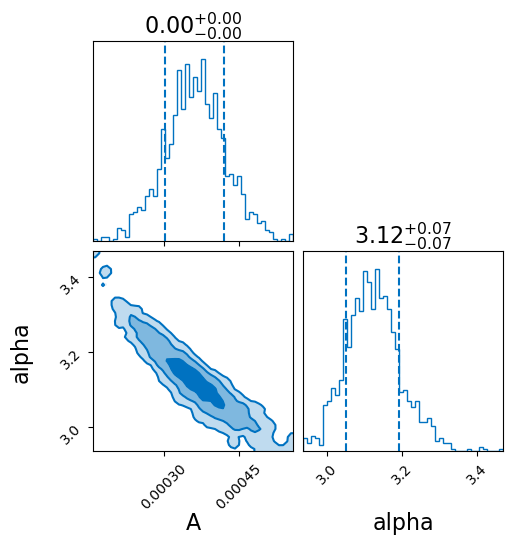

In [11]:
# A few simple setup steps
label = 'GWB_powerlaw'
outdir = 'outdir'

cleanup_dir(outdir)

Amin,Amax,alpha_min,alpha_max=1e-10,1e-3,-5,5
    

fref=25

likelihood = BasicPowerLawGWBLikelihood(Y_f[1:],var_f[1:],freqs[1:],fref)
priors = dict(A=bilby.core.prior.Uniform(Amin,Amax, 'A'),
              alpha=bilby.core.prior.Uniform(alpha_min,alpha_max, 'alpha'))

# And run sampler
result = bilby.run_sampler(
    likelihood=likelihood, priors=priors, sampler='dynesty', npoints=500,
    walks=10, outdir=outdir, label=label,maxmcmc=50000)
result.plot_corner()

In [12]:
A=result.samples[:,0]
alpha=result.samples[:,1]

Text(0.5, 0, '')

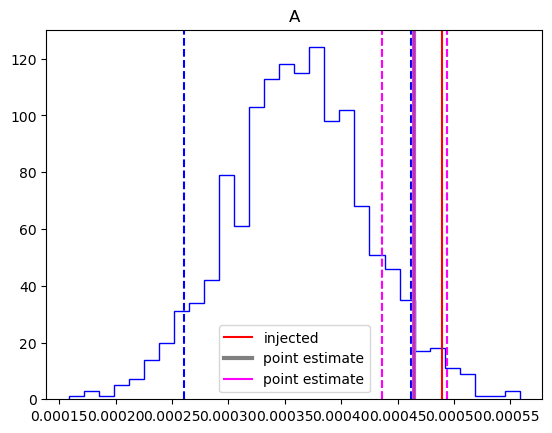

In [13]:
plt.hist(A,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(A,5),color='blue',linestyle='--')
plt.axvline(np.percentile(A,95),color='blue',linestyle='--')

plt.axvline(Y_theor,color='red', label='injected')


plt.axvline(Y_opt,color='grey', linewidth=3, label='point estimate')
plt.axvline(Y_opt+sig_opt_alt,color='grey', linestyle='--')
plt.axvline(Y_opt-sig_opt_alt,color='grey', linestyle='--')

plt.axvline(Y_opt,color='magenta', linestyle='-', label='point estimate')
plt.axvline(Y_opt+sig_opt,color='magenta', linestyle='--')
plt.axvline(Y_opt-sig_opt,color='magenta', linestyle='--')

plt.legend()

plt.title('A')
plt.xlabel('')

Text(0.5, 0, '')

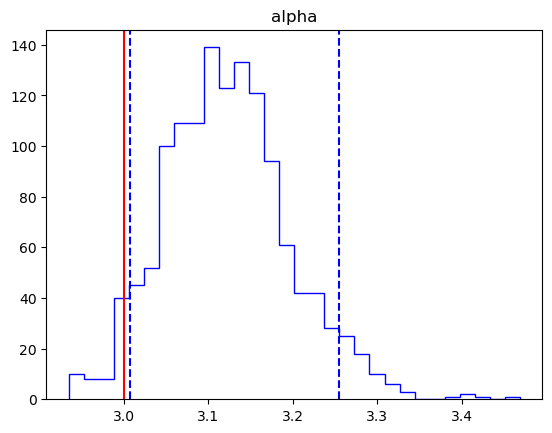

In [14]:
plt.hist(alpha,bins=30,histtype='step',color='blue')
plt.axvline(np.percentile(alpha,5),color='blue',linestyle='--')
plt.axvline(np.percentile(alpha,95),color='blue',linestyle='--')

plt.axvline(3,color='red')

plt.title('alpha')
plt.xlabel('')